## 1. Problem Statement
### Analyzing: Hot water cooled electronics: Exergy analysis and waste heat reuse feasibility

This article was published in the International Journal of Heat and Mass Transfer in 2012: https://www.sciencedirect.com/science/article/pii/S0017931012004553?via%3Dihub

They use a flow loop to cool a heat sink that is attached to a computer chip:

They perform first law (energy based) and second law (exergy based) analysis to understand how much waste heat they can recover and the quality of that recovered heat for potential reuse in building heating. They state that data centers require significant cooling, which is currently achieved with air. That air cooling requires a significant amount of energy. They state that liquid cooling should provide better heat transfer efficiency, and they hypothesize that if they use "hot water" to cool the chips, that this would keep the waste heat output from computers at higher exergy. This means it may have better potential for resuse, for example, in building heating. Instead of requiring extra energy for cooling, the cooling process itself can actulally bring a benefit by reducing the building heating energy requirements.

### Analysis
- define second law efficiency
- determine exergy terms
- calculate second law efficiency for different conditions

## 2. Schematic 
See lecture slides. See green loop in Figure 2 [here](https://www.sciencedirect.com/science/article/pii/S0360544212003350).

## 3. Assumptions and Approximations
* **Control Volume** (mass crosses the boundary).
* **Properties** We can use `pyCalor` to determine properties. 
* **Steady-flow process** ($\Delta m_\text{CV}= 0$, $\Delta E_\text{CV}= 0$, $\Delta S_\text{CV}= 0$).
* We have a single inlet and outlet ($\dot{m}_\text{in}$ and $\dot{m}_\text{out}$).
* **No Shaft Work**
* **Isobaric**: Heat exchangers are isobaric devices. (Justification: Negligible changes in pressure between the inlet and exit.)

## 4. Physical Laws
### Analyzing: Hot water cooled electronics: Exergy analysis and waste heat reuse feasibility

Second law efficiency can be defined as:

$$\eta_\text{II} = \frac{\text{Exergy recovered}}{\text{Exergy expended}} $$

It is instructive to first look at the second law efficiency of a simple electric heater:

$$\eta_\text{II,electric heater} = \frac{\dot{X}_\text{recovered}}{\dot{X}_\text{expended}} = \frac{\dot{X}_\text{heat}}{\dot{W}_\text{e}} = \frac{\dot{Q}_\text{e} \left(1 - T_0/T_\text{H} \right)}{\dot{W}_\text{e}} = 1 - \frac{T_0}{T_\text{H}} $$

In the case of electronics cooling, there is exergy expended on running the computer and pump and the recovered exergy is heat exergy:

$$\eta_\text{II} = \frac{\dot{X}_\text{recovered}}{\dot{X}_\text{expended}} = \frac{\dot{X}_\text{outlet}}{\dot{X}_\text{inlet} + \dot{X}_\text{el} + \dot{P}_\text{pump}}$$

We can write the inlet and outlet exergy terms using this equation:

$$ \dot{X}_\text{flow} = \dot{m}\left[\left(h - h_0\right) - T_0 \left( s - s_0 \right) \right]$$

In the study, they say that 100 W of electrical power is used for the processor chip, which is pure exergy. 

The maximum upper temperature where the chip can operate safely is this temperature, $T_\text{max}$.

They say that the pump has a flow rate of 1 L/min and that that the pump requires 0.24 W of power. The power for a pump can be estimated as:

$$\dot{P} = \Delta p \dot{V} $$

All of the electrical exergy will become heat. Therefore, the heat transferred from the chip to the water is equal to the electrical work transferred into the chip. Therefore, 

$$T_\text{out} - T_\text{in} = \frac{\dot{Q}}{\dot{m}c_p} $$

For the exergy analysis, recall that: 
$$ \dot{X}_\text{flow} = \dot{m}\left[\left(h - h_0\right) - T_0 \left( s - s_0 \right) \right]$$

$$\eta_\text{II} = \frac{\dot{X}_\text{recovered}}{\dot{X}_\text{expended}} = \frac{\dot{X}_\text{outlet}}{\dot{X}_\text{inlet} + \dot{X}_\text{el} + \dot{P}_\text{pump}}$$

We would like to study the effect of inlet water temperature on second law efficiency. 
Therefore, that will be an independent variable. What we need to know though is the outlet temperature from the device. 
For this, we will assume that the flow rate is kept constant. 
Therefore, from Newton's cooling law, we can estimate what the outlet temperature increase will be relative to the inlet temperature. 
We can estimate the mean temperature increase by assuming a constant value of specific heat, $c_p$.

Our approach:
- define the inlet temperature, which defines the properties.
- the electrical exergy defines the heat transferred to the fluid, which determines the outlet temperature and properties. 
- calculate the flow exergy terms. 
- calculate the second law efficiency.

In [16]:
# 5 Properties (Code Cell)
!pip install pyCalor

from pyCalor import thermo as th

V_LperMin = 1
V_m3perS = (V_LperMin/60)/1000
rho0 = 1000 # kg per m3
Xel_W = 100
cp_JperKg = 4184
T0_K = 300
Tmax_K = T0_K + 60
p0_MPa = 101325/1e6
substance = 'water'

dP_Pa = 2e5
P_W = V_m3perS*dP_Pa; print("P_W=",P_W)

st0 = th.state(substance,T=T0_K, p=(p0_MPa,'Mpa'))
h0_kJperKg = st0.h
s0_kJperKgperK = st0.s

P_W= 3.3333333333333335


0.016666666666666666
The temperature increase is: 1.4340 K


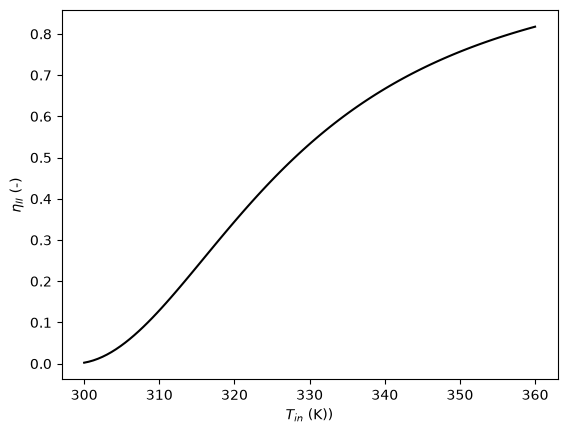

In [19]:
# 6 Calculations (Code Cell)

mdot_kgPers = V_m3perS*rho0
print(mdot_kgPers)

# All of the electrical exergy will become heat. Therefore, the heat transferred from the chip to the water is:
Q_W = Xel_W

dT_K = Q_W / (mdot_kgPers*cp_JperKg )
print('The temperature increase is: {0:1.4f} K'.format(dT_K))

import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.clf()
steps = 100

T = np.linspace(T0_K, Tmax_K, steps) # range of temperatures
h0 = np.linspace(h0_kJperKg, h0_kJperKg, steps) # range of temperatures
T0 = np.linspace(T0_K, T0_K, steps)
s0 = np.linspace(s0_kJperKgperK, s0_kJperKgperK, steps)
Xel = np.linspace(Xel_W, Xel_W, steps)
P = np.linspace(P_W, P_W, steps)

sin = [s.s for s in [th.state(substance,T=t, p=(p0_MPa,'Mpa')) for t in T]]
hin = [s.h for s in [th.state(substance,T=t, p=(p0_MPa,'Mpa')) for t in T]]

sout = [s.s for s in [th.state(substance,T=t+dT_K, p=(p0_MPa,'Mpa')) for t in T]]
hout = [s.h for s in [th.state(substance,T=t+dT_K, p=(p0_MPa,'Mpa')) for t in T]]

Xdot_in = mdot_kgPers*(hin - h0 - T0*(sin - s0))
Xdot_out = mdot_kgPers*(hout - h0 - T0*(sout - s0))

eta = Xdot_out/(Xdot_in + (Xel/1000) + (P/1000))

plt.plot(T, eta, 'k-')

plt.xlabel('$T_{in}$ (K))')
plt.ylabel('$\eta_{II}$ (-)')
plt.savefig('../lectures/figures/eta-Tin.pdf')

## 7. Summary and Reasoning

This is simplified analysis, but it shows the plausibility of using hot water to cool electronics in order to facilitate heat reuse. This can minimize the overall system carbon footprint because the recovered heat can replace significant amounts of fossil fuels used in secondary applications such as building heating.